In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/5G_models/', exist_ok=True)

Mounted at /content/drive


In [1]:
import os
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from fastai.tabular.all import *
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, SplineTransformer

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.autograd import Variable
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts

warnings.simplefilter("ignore")

ModuleNotFoundError: No module named 'fastai'

In [ ]:
def periodic_spline_transformer(period, n_splines=None, degree=3):
    if n_splines is None:
        n_splines = period
    n_knots = n_splines + 1
    return SplineTransformer(
        degree=degree,
        n_knots=n_knots,
        knots=np.linspace(0, period, n_knots).reshape(n_knots, 1),
        extrapolation="periodic",
        include_bias=True)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
seed_everything(seed=42)

In [ ]:
set_seed(42)
seed_everything(seed=42)

# Load single combined dataset
df_total = pd.read_csv("ECdata.csv", parse_dates=['Time'])
df_cell = pd.read_csv("CLdata.csv", parse_dates=['Time'])
df_bs = pd.read_csv("BSinfo.csv")

df_features = df_cell.merge(df_bs, on=['BS', 'CellName'], how='outer')
df_features = df_features[df_features['CellName'] == 'Cell0'].reset_index(drop=True)

# Since there's only one file, create a time-based train/test split
# Use last 20% of time as test
time_threshold = df_total['Time'].quantile(0.8)
df_total['split'] = np.where(df_total['Time'] <= time_threshold, 'train', 'test')

df_total = df_total.merge(df_features, on=['BS', 'Time'], how='left')
df_total['ID'] = df_total['Time'].astype(str) + "_" + df_total['BS']
df_total['BS'] = df_total['BS'].str.replace(r'[a-zA-Z_]', '', regex=True).astype(int)

for col in ['RUType', 'Mode']:
    df_total[col] = df_total[col].str.replace(r'[a-zA-Z]', '', regex=True).astype(int)

df_total.sort_values(['BS', 'Time'], ascending=True, ignore_index=True, inplace=True)
df_total['day'] = df_total['Time'].dt.day
df_total['weekday_number'] = df_total['Time'].dt.weekday
df_total['hour'] = df_total['Time'].dt.hour

hour_df = df_total[['hour']].copy()
splines = periodic_spline_transformer(24, n_splines=12).fit_transform(hour_df)
splines_df = pd.DataFrame(splines, columns=[f"hour_spline_{i}" for i in range(splines.shape[1])])
df_total = pd.concat([df_total, splines_df], axis=1)

df_total = df_total.sort_values(['BS', 'Time'], ascending=True, ignore_index=True)

all_shits = list(np.arange(1, 4))
for shift_i in tqdm(all_shits):
    for col in ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode6', 'Time', 'Energy']:
        df_total[f'{col}_T-{shift_i}'] = df_total.groupby(['BS'])[col].shift(shift_i)

for shift_i in tqdm(all_shits):
    df_total[f'Time_T-{shift_i}_hours_elapsed'] = (
        df_total[f'Time_T-{shift_i}'] - df_total['Time']
    ).dt.total_seconds() / 3600
    del df_total[f'Time_T-{shift_i}']

print(df_total.shape)

num_bins = 100
df_total['load_bin'] = pd.cut(
    df_total['load'],
    bins=[round(i, 2) for i in list(np.arange(0, 1.01, 0.01))],
    labels=[f'{i}' for i in range(num_bins)]
)
df_total['load_bin'] = df_total['load_bin'].astype(float).fillna(-1).astype(int)

print(df_total.shape)

100%|██████████| 3/3 [00:00<00:00, 219.18it/s]

(92629, 55)
(92629, 56)


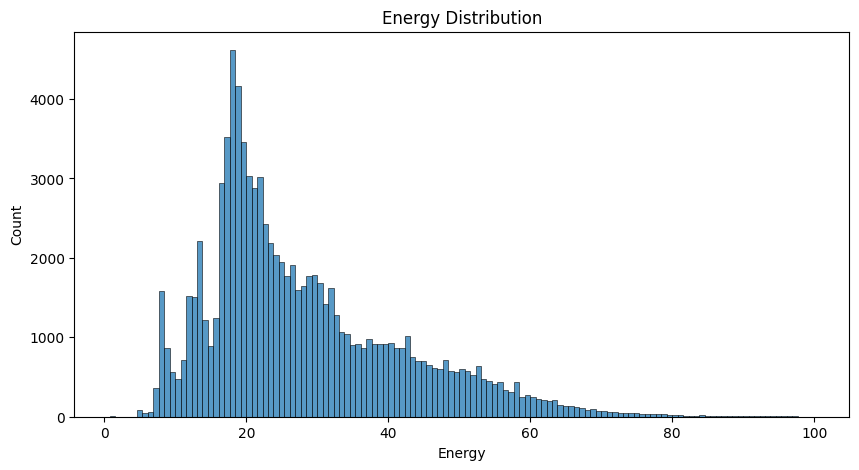

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_total['Energy'])
plt.title("Energy Distribution")
plt.show()

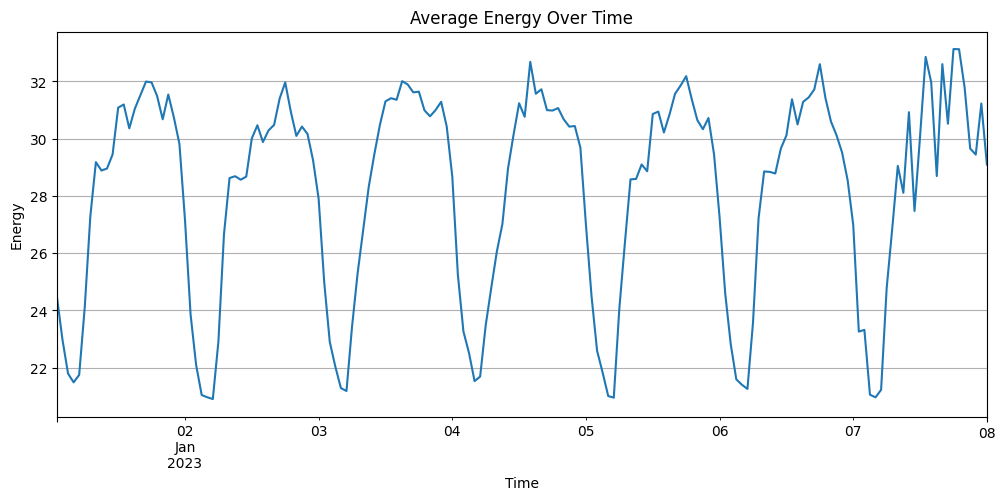

In [ ]:
df_plot = df_total.groupby('Time')['Energy'].mean().sort_index()

plt.figure(figsize=(12,5))
df_plot.plot()

plt.title("Average Energy Over Time")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.grid(True)

plt.show()

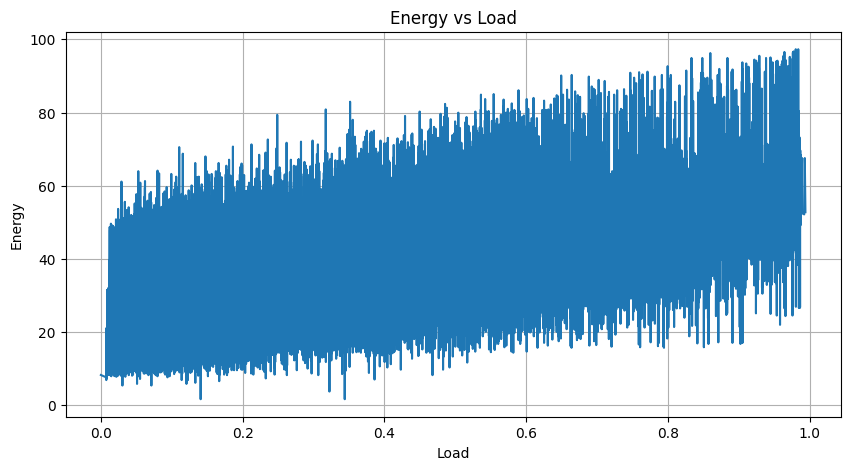

In [ ]:
import matplotlib.pyplot as plt

df_plot = df_total.groupby('load')['Energy'].mean().sort_index()

plt.figure(figsize=(10,5))
df_plot.plot()

plt.title("Energy vs Load")
plt.xlabel("Load")
plt.ylabel("Energy")
plt.grid(True)

plt.show()

In [ ]:
set_seed(42)
seed_everything(seed=42)

from scipy.signal import savgol_filter as sg
from scipy.signal import sosfiltfilt, butter, sosfilt, sosfilt_zi

def add_sg(df):
    w_default = 5
    p = 3
    for si in tqdm(df.BS.unique()):
        index = df.BS == si
        n = index.sum()

        # window must be >= polyorder+1 and <= n, and must be odd
        w = min(w_default, n)
        if w % 2 == 0:
            w -= 1          # make odd
        if w < p + 1:
            # not enough points to fit even a minimal window — skip
            df.loc[index, 'load_smooth'] = df.loc[index, 'load']
            df.loc[index, 'load_diff']   = 0.0
            df.loc[index, 'load_diff2']  = 0.0
            df.loc[index, 'load_diff3']  = 0.0
            continue

        df.loc[index, 'load_smooth'] = sg(df[index].load, w, p)
        df.loc[index, 'load_diff']   = sg(df[index].load, w, p, 1)
        df.loc[index, 'load_diff2']  = sg(df[index].load, w, p, 2)
        df.loc[index, 'load_diff3']  = sg(df[index].load, w, p, 3)

add_sg(df_total)
print(df_total.shape)

def add_sosfiltfilt(df):
    for si in tqdm(df.BS.unique()):
        index = df.BS == si
        n = index.sum()
        load_vals = df[index].load.values

        sos  = butter(4, 0.125, output='sos')
        sos8 = butter(8, 0.125, output='sos')

        # sosfiltfilt needs at least 3*(max_filter_order) samples;
        # fall back to raw load if too few points
        min_len = 3 * 8 * 2   # 3 * (order * 2 sections)
        if n < min_len:
            df.loc[index, 'load_sosfiltfilt'] = load_vals
            df.loc[index, 'load_sosfilt']     = load_vals
            continue

        zi = load_vals[:4].mean() * sosfilt_zi(sos8)
        df.loc[index, 'load_sosfiltfilt']       = sosfiltfilt(sos,  load_vals)
        df.loc[index, 'load_sosfilt'], _         = sosfilt(sos8, load_vals, zi=zi)

add_sosfiltfilt(df_total)
print(df_total.shape)

100%|██████████| 923/923 [00:09<00:00, 92.63it/s] 


(92629, 59)


100%|██████████| 923/923 [00:05<00:00, 155.61it/s]

(92629, 59)


In [ ]:
set_seed(42)
seed_everything(seed=42)

cols_to_drop = ['CellName', 'ESMode4', 'Time']
optional_cols = ['w']
cols_to_drop += [c for c in optional_cols if c in df_total.columns]
df_total.drop(columns=cols_to_drop, inplace=True, errors='ignore')

id_variable = 'ID'
version_nb = 'v4'
TARGET = 'Energy'

train_df = df_total[df_total['split'] == 'train'].reset_index(drop=True)
test_df  = df_total[df_total['split'] == 'test'].reset_index(drop=True)

train_cols = [i for i in train_df.columns if i not in ['ID', 'Energy', 'split', 'BS', 'ESMode6']]

# Only keep categorical cols that actually exist in train_cols
categorical_cols = [c for c in ['RUType', 'Mode', 'load_bin'] if c in train_cols]

print(f"train_cols ({len(train_cols)}):", train_cols)
print(f"categorical_cols: {categorical_cols}")
print(train_df[train_cols].shape, test_df[train_cols].shape)

train_cols (54): ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode5', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'day', 'weekday_number', 'hour', 'hour_spline_0', 'hour_spline_1', 'hour_spline_2', 'hour_spline_3', 'hour_spline_4', 'hour_spline_5', 'hour_spline_6', 'hour_spline_7', 'hour_spline_8', 'hour_spline_9', 'hour_spline_10', 'hour_spline_11', 'load_T-1', 'ESMode1_T-1', 'ESMode2_T-1', 'ESMode3_T-1', 'ESMode6_T-1', 'Energy_T-1', 'load_T-2', 'ESMode1_T-2', 'ESMode2_T-2', 'ESMode3_T-2', 'ESMode6_T-2', 'Energy_T-2', 'load_T-3', 'ESMode1_T-3', 'ESMode2_T-3', 'ESMode3_T-3', 'ESMode6_T-3', 'Energy_T-3', 'Time_T-1_hours_elapsed', 'Time_T-2_hours_elapsed', 'Time_T-3_hours_elapsed', 'load_bin', 'load_smooth', 'load_diff', 'load_diff2', 'load_diff3', 'load_sosfiltfilt', 'load_sosfilt']
categorical_cols: ['RUType', 'Mode', 'load_bin']
(74553, 54) (18076, 54)


In [ ]:
set_seed(42)
seed_everything(seed=42)

remove_non_unique_cols = []
print('train single values ..')
for col in train_df:
    if col in train_cols and col not in ['ESMode5']:
        if train_df[col].nunique() <= 1:
            remove_non_unique_cols.append(col)
            print(col, ":", train_df[col].nunique())

print('test single values ..')
for col in test_df:
    if col in train_cols and col not in ['ESMode5']:
        if test_df[col].nunique() <= 1:
            remove_non_unique_cols.append(col)
            print(col, ":", test_df[col].nunique())

print('\n', remove_non_unique_cols)

for col in train_df:
    if col in train_cols:
        if train_df[col].isnull().sum() / len(train_df) >= 0.95:
            print(col, ":", train_df[col].isnull().sum() / len(train_df))
            remove_non_unique_cols.append(col)

for col in test_df:
    if col in train_cols:
        if test_df[col].isnull().sum() / len(test_df) >= 0.95:
            print(col, ":", test_df[col].isnull().sum() / len(test_df))
            remove_non_unique_cols.append(col)

print(len(train_cols))
train_cols = [col for col in train_cols if col not in remove_non_unique_cols]
print(len(train_cols))
print(train_cols)

train single values ..
ESMode3 : 1
ESMode3_T-1 : 1
ESMode3_T-2 : 1
ESMode3_T-3 : 1
test single values ..
Mode : 1
ESMode6_T-1 : 1
ESMode6_T-2 : 1
ESMode6_T-3 : 1

 ['ESMode3', 'ESMode3_T-1', 'ESMode3_T-2', 'ESMode3_T-3', 'Mode', 'ESMode6_T-1', 'ESMode6_T-2', 'ESMode6_T-3']
54
46
['load', 'ESMode1', 'ESMode2', 'ESMode5', 'RUType', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'day', 'weekday_number', 'hour', 'hour_spline_0', 'hour_spline_1', 'hour_spline_2', 'hour_spline_3', 'hour_spline_4', 'hour_spline_5', 'hour_spline_6', 'hour_spline_7', 'hour_spline_8', 'hour_spline_9', 'hour_spline_10', 'hour_spline_11', 'load_T-1', 'ESMode1_T-1', 'ESMode2_T-1', 'Energy_T-1', 'load_T-2', 'ESMode1_T-2', 'ESMode2_T-2', 'Energy_T-2', 'load_T-3', 'ESMode1_T-3', 'ESMode2_T-3', 'Energy_T-3', 'Time_T-1_hours_elapsed', 'Time_T-2_hours_elapsed', 'Time_T-3_hours_elapsed', 'load_bin', 'load_smooth', 'load_diff', 'load_diff2', 'load_diff3', 'load_sosfiltfilt', 'load_sosfilt']


In [ ]:
set_seed(42)
seed_everything(seed=42)

Nfold = 10
Inference = False

if Inference:
    print('Data has been splitted...')
else:
    train_df['fold'] = 0
    strafy_bin = train_df['BS'].astype('int')

    skf = GroupKFold(n_splits=Nfold)
    for i, (_, train_index) in enumerate(skf.split(train_df.index, train_df.index, strafy_bin)):
        train_df.loc[train_index, 'fold'] = i

In [ ]:
set_seed(42)
seed_everything(seed=42)

def mae(preds, targs):
    return (abs(targs - preds)).mean()

def mape(preds, targs):
    return (abs((targs - preds) / targs)).mean()

def fit_fastai(Nfolds, train_df, test_df, train_cols, cat_feats, TARGET, model_path):

    # Guard: only use cat_feats that are actually present in train_cols
    cat_feats = [c for c in cat_feats if c in train_cols]

    oof_pred_fastai = np.zeros(train_df.shape[0], dtype=np.float32)
    pred_fastai     = np.zeros(test_df.shape[0],  dtype=np.float32)
    scores, scores_pvt = [], []

    train_df_fast = train_df[train_cols + [TARGET]].copy()
    test_df = test_df.copy()

    for col in train_df_fast.columns:
        if col not in cat_feats:
            train_df_fast[col] = train_df_fast[col].fillna(0)
            test_df[col]       = test_df[col].fillna(0)
        else:
            most_frequent = train_df_fast[col].mode().iloc[0]
            train_df_fast[col] = train_df_fast[col].fillna(most_frequent)
            test_df[col]       = test_df[col].fillna(most_frequent)

    train_df_fast[cat_feats] = train_df_fast[cat_feats].astype('category')
    test_df[cat_feats]       = test_df[cat_feats].astype('category')

    cont_nn = [c for c in train_cols if c not in cat_feats]
    cat_nn  = cat_feats
    layers  = [256, 512, 1024, 512, 256]

    for fold in range(Nfolds):
        print("*" * 10, f'Fold-{fold+1}', "*" * 10)
        train_idx = train_df.loc[train_df['fold'] != fold].index
        valid_idx = train_df.loc[train_df['fold'] == fold].index
        splits = (L(list(train_idx)), L(list(valid_idx)))

        dls = TabularPandas(
            train_df_fast, [Categorify, Normalize], cat_nn, cont_nn,
            splits=splits, y_names=TARGET, reduce_memory=False
        ).dataloaders(1024)

        learn = tabular_learner(
            dls, layers=layers, n_out=1, y_range=(0, 100),
            loss_func=mae, metrics=AccumMetric(mae)
        )
        learn.fit_one_cycle(
            100, 2e-3,
            cbs=SaveModelCallback(monitor='mae', comp=np.less, fname=f'nn_model_{fold}')
        )

        val_df = train_df.loc[train_df['fold'] == fold]
        val_dl = dls.test_dl(val_df[train_cols].fillna(0))
        preds, _ = learn.get_preds(dl=val_dl)
        oof_pred_fastai[val_df.index] = preds.squeeze().numpy()

        score     = mean_absolute_error(val_df[TARGET], oof_pred_fastai[val_df.index])
        score_pvt = mean_absolute_percentage_error(val_df[TARGET], oof_pred_fastai[val_df.index])
        scores.append(score)
        scores_pvt.append(score_pvt)
        print(f'MAE  Fold-{fold+1}: {np.round(score, 3)}')
        print(f'MAPE Fold-{fold+1}: {np.round(score_pvt, 3)}')

        test_dl = dls.test_dl(test_df[train_cols])
        preds, _ = learn.get_preds(dl=test_dl)
        pred_fastai += preds.squeeze().numpy() / Nfolds

    score     = mean_absolute_error(train_df[TARGET], oof_pred_fastai)
    score_pvt = mean_absolute_percentage_error(train_df[TARGET], oof_pred_fastai)
    print(f'OOF MAE:      {np.round(score, 3)}')
    print(f'Average MAE:  {np.round(np.mean(scores), 3)}+/-{np.round(np.std(scores), 3)}')
    print(f'OOF MAPE:     {np.round(score_pvt, 3)}')
    print(f'Average MAPE: {np.round(np.mean(scores_pvt), 3)}+/-{np.round(np.std(scores_pvt), 3)}')

    return oof_pred_fastai, pred_fastai

In [ ]:
set_seed(42)
seed_everything(seed=42)

if Inference:
    model_path = '/content/drive/MyDrive/5G_models/fastai_models/'
else:
    model_path = './'

oof_pred_fastai, pred_fastai = fit_fastai(Nfold, train_df, test_df, train_cols, categorical_cols, TARGET, model_path)

train_df = train_df.copy()
train_df['oof_fastai'] = oof_pred_fastai

********** Fold-1 **********


epoch,train_loss,valid_loss,mae,time
0,10.372375,6.023855,6.023855,00:11
1,7.136843,4.532085,4.532085,00:10
2,5.546550,3.283036,3.283036,00:10
3,4.593881,3.016814,3.016814,00:12
4,3.969068,2.856562,2.856561,00:22
5,3.552965,2.456888,2.456888,00:17
6,3.267707,2.343540,2.343540,00:28
7,2.873643,1.884700,1.884700,00:20
8,2.835494,2.003539,2.003539,00:16
9,2.601726,2.161704,2.161704,00:11


Better model found at epoch 0 with mae value: 6.023855209350586.
Better model found at epoch 1 with mae value: 4.532085418701172.
Better model found at epoch 2 with mae value: 3.283036470413208.
Better model found at epoch 3 with mae value: 3.0168137550354004.
Better model found at epoch 4 with mae value: 2.8565614223480225.
Better model found at epoch 5 with mae value: 2.456888198852539.
Better model found at epoch 6 with mae value: 2.3435404300689697.
Better model found at epoch 7 with mae value: 1.884699821472168.
Better model found at epoch 11 with mae value: 1.6460336446762085.
Better model found at epoch 12 with mae value: 1.6136225461959839.
Better model found at epoch 13 with mae value: 1.2616984844207764.
Better model found at epoch 16 with mae value: 1.2317057847976685.
Better model found at epoch 18 with mae value: 1.1469820737838745.
Better model found at epoch 19 with mae value: 1.0846062898635864.
Better model found at epoch 29 with mae value: 0.9846763014793396.
Better m

MAE  Fold-1: 0.721
MAPE Fold-1: 0.03


********** Fold-2 **********


...

********** Fold-10 **********


epoch,train_loss,valid_loss,mae,time
0,10.723502,10.217080,10.217080,00:11
1,7.254645,6.700929,6.700929,00:11
2,5.558862,5.594800,5.594799,00:10
3,4.550793,4.027075,4.027076,00:11
4,3.972378,3.484566,3.484566,00:11
5,3.715607,3.143254,3.143254,00:11
6,3.298173,3.321745,3.321745,00:11
7,3.148292,2.933207,2.933207,00:11
8,2.994466,2.411629,2.411630,00:11
9,2.642193,2.011912,2.011912,00:11


Better model found at epoch 0 with mae value: 10.217080116271973.
Better model found at epoch 1 with mae value: 6.700929164886475.
Better model found at epoch 2 with mae value: 5.594799041748047.
Better model found at epoch 3 with mae value: 4.02707576751709.
Better model found at epoch 4 with mae value: 3.4845664501190186.
Better model found at epoch 5 with mae value: 3.143254041671753.
Better model found at epoch 7 with mae value: 2.9332070350646973.
Better model found at epoch 8 with mae value: 2.4116296768188477.
Better model found at epoch 9 with mae value: 2.0119121074676514.
Better model found at epoch 11 with mae value: 1.757987380027771.
Better model found at epoch 12 with mae value: 1.7054879665374756.
Better model found at epoch 16 with mae value: 1.6801177263259888.
Better model found at epoch 17 with mae value: 1.567970871925354.
Better model found at epoch 18 with mae value: 1.302000641822815.
Better model found at epoch 19 with mae value: 1.274627447128296.
Better model 

MAE  Fold-10: 0.821
MAPE Fold-10: 0.028


OOF MAE:      0.834
Average MAE:  0.834+/-0.068
OOF MAPE:     0.032
Average MAPE: 0.032+/-0.002


In [ ]:
set_seed(42)
seed_everything(seed=42)

submission_fastai = pd.DataFrame(data={'Time': test_df['ID'].values, 'Energy': pred_fastai})
print(submission_fastai.head())
submission_fastai.to_csv('submission_fastai.csv', index=False)

                      Time     Energy
0  2023-01-06 00:00:00_B_0  66.255684
1  2023-01-06 03:00:00_B_0  52.219940
2  2023-01-06 04:00:00_B_0  51.743874
3  2023-01-06 05:00:00_B_0  53.254555
4  2023-01-06 07:00:00_B_0  77.895905


In [ ]:
if not Inference:
    import shutil
    shutil.copy('/content/submission_fastai.csv', '/content/drive/MyDrive/5G_models/')
    shutil.copytree('/content/models/', '/content/drive/MyDrive/5G_models/fastai_models/', dirs_exist_ok=True)
    print("Saved to Drive!")

Saved to Drive!


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import backend as K
from tensorflow.keras.utils import get_custom_objects
from keras.layers import Activation

set_seed(42)
seed_everything(seed=42)
tf.random.set_seed(42)

In [ ]:
set_seed(42)
seed_everything(seed=42)
tf.random.set_seed(42)

def keras_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=50, verbose=0,
    mode='min', restore_best_weights=True)

plateau = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.25, patience=8, verbose=0,
    mode='min')

def swish(x, beta=1):
    return x * tf.nn.sigmoid(beta * x)

def mish(x, beta=1):
    return x * tf.math.tanh(tf.math.softplus(x))

get_custom_objects().update({'swish': Activation(swish)})
get_custom_objects().update({'mish': Activation(mish)})

In [ ]:
set_seed(42)
seed_everything(seed=42)
tf.random.set_seed(42)

def base_model(hidden_units, embedding_size, train_cols, categorical_cols, uniques):

    n_cont = 0
    initial_inputs = []
    for col in categorical_cols:
        temp_input = keras.Input(shape=(1,), name=col)
        n_cont += 1
        initial_inputs.append(temp_input)

    num_input = keras.Input(shape=(len(train_cols) - n_cont,), name='num_data')
    initial_inputs.append(num_input)

    all_inputs = []
    for i, col in enumerate(categorical_cols):
        temp_embedded = keras.layers.Embedding(
            int(uniques[col]), embedding_size,
            input_length=1, name=f'{col}_embedding'
        )(initial_inputs[i])
        temp_flattened = keras.layers.Flatten()(temp_embedded)
        all_inputs.append(temp_flattened)

    all_inputs.append(num_input)
    out = keras.layers.Concatenate()(all_inputs)

    for n_hidden in hidden_units:
        out = keras.layers.Dense(n_hidden, activation='swish')(out)

    out = keras.layers.Dense(1, activation='linear', name='prediction')(out)

    model = keras.Model(inputs=initial_inputs, outputs=out)
    return model

In [ ]:
set_seed(42)
seed_everything(seed=42)
tf.random.set_seed(42)

def fit_keras_nn(Nfolds, train_df, test_df, train_cols, cat_cols, TARGET, model_path):
    model_name = 'Keras_NN'
    oof_keras  = np.zeros(train_df.shape[0])
    pred_keras = np.zeros(test_df.shape[0])
    scores, scores_pvt = [], []

    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df = train_df.fillna(0)
    test_df  = test_df.fillna(0)

    # Guard: only use cat_cols that are actually present in train_cols
    cat_cols  = [c for c in cat_cols if c in train_cols]
    cont_cols = [c for c in train_cols if c not in cat_cols]

    uniques = {}
    for col in cat_cols:
        le = LabelEncoder()
        le.fit(pd.concat([train_df[col], test_df[col]]))
        train_df[col] = le.transform(train_df[col].values)
        test_df[col]  = le.transform(test_df[col].values)
        uniques[col]  = len(pd.concat([train_df[col], test_df[col]], axis=0).unique())

    scaler = StandardScaler().fit(pd.concat([train_df[cont_cols], test_df[cont_cols]], axis=0))
    train_df[cont_cols] = scaler.transform(train_df[cont_cols].values)
    test_df[cont_cols]  = scaler.transform(test_df[cont_cols].values)

    test_inputs = [test_df[col].values for col in cat_cols]
    test_inputs.append(test_df[cont_cols].values)

    for fold in range(Nfolds):
        print("*" * 10, f'Fold-{fold+1}', "*" * 10)
        X_train = train_df.loc[train_df.fold != fold, train_cols]
        y_train = train_df.loc[train_df.fold != fold, TARGET]
        X_val   = train_df.loc[train_df.fold == fold, train_cols]
        y_val   = train_df.loc[train_df.fold == fold, TARGET]

        model = base_model(
            hidden_units=(256, 512, 1024, 512, 256), embedding_size=16,
            train_cols=train_cols, categorical_cols=cat_cols, uniques=uniques
        )
        model.compile(
            keras.optimizers.Adam(learning_rate=0.002),
            loss=keras_mae
        )

        train_inputs = [X_train[col].values for col in cat_cols]
        train_inputs.append(X_train[cont_cols].values)

        val_inputs = [X_val[col].values for col in cat_cols]
        val_inputs.append(X_val[cont_cols].values)

        model.fit(
            train_inputs, y_train.values,
            batch_size=1024, epochs=1000,
            validation_data=(val_inputs, y_val.values),
            callbacks=[es, plateau],
            validation_batch_size=len(y_val),
            shuffle=True, verbose=1
        )

        model.save(f"{model_name}_{fold}.h5")

        preds     = model.predict(val_inputs).reshape(1, -1)[0]
        score     = mean_absolute_error(y_val.values, preds)
        score_pvt = mean_absolute_percentage_error(y_val.values, preds)
        scores.append(score)
        scores_pvt.append(score_pvt)
        oof_keras[X_val.index] = preds

        print(f'MAE  Fold-{fold+1}: {np.round(score, 3)}')
        print(f'MAPE Fold-{fold+1}: {np.round(score_pvt, 3)}')

        pred_keras += model.predict(test_inputs).reshape(1, -1)[0] / Nfolds

    score     = mean_absolute_error(train_df[TARGET], oof_keras)
    score_pvt = mean_absolute_percentage_error(train_df[TARGET], oof_keras)
    print(f'OOF MAE:      {np.round(score, 3)}')
    print(f'Average MAE:  {np.round(np.mean(scores), 3)}+/-{np.round(np.std(scores), 3)}')
    print(f'OOF MAPE:     {np.round(score_pvt, 3)}')
    print(f'Average MAPE: {np.round(np.mean(scores_pvt), 3)}+/-{np.round(np.std(scores_pvt), 3)}')

    return oof_keras, pred_keras

In [ ]:
set_seed(42)
seed_everything(seed=42)
tf.random.set_seed(42)

if Inference:
    model_path = '/content/drive/MyDrive/5G_models/keras_models/'
else:
    model_path = '/content/'

oof_pred_keras, pred_keras = fit_keras_nn(Nfold, train_df, test_df, train_cols, categorical_cols, TARGET, model_path)
train_df = train_df.copy()
train_df['oof_keras'] = oof_pred_keras

# Copy keras models and submission to Drive after training
if not Inference:
    import shutil, glob, os
    os.makedirs('/content/drive/MyDrive/5G_models/keras_models/', exist_ok=True)
    for f in glob.glob('/content/Keras_NN_*.h5'):
        shutil.copy(f, '/content/drive/MyDrive/5G_models/keras_models/')
    print("Keras models copied to Drive!")

********** Fold-1 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 331ms/step - loss: 5.0515 - val_loss: 1.2922 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 274ms/step - loss: 1.3500 - val_loss: 1.1287 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - loss: 1.2167 - val_loss: 1.0509 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - loss: 1.2166 - val_loss: 1.1078 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - loss: 1.1638 - val_loss: 1.0094 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - loss: 1.1462 - val_loss: 1.2759 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - loss: 1.1359 - val_loss: 1.0853 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step - loss: 1.1020 - val_loss: 0.9801 - learning_rate: 0.0020
Epoch 9/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - loss: 1.12

234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE  Fold-1: 0.685
MAPE Fold-1: 0.029
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
********** Fold-2 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - loss: 4.6832 - val_loss: 1.4855 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - loss: 1.3940 - val_loss: 1.3348 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 196ms/step - loss: 1.2791 - val_loss: 1.3103 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - loss: 1.2307 - val_loss: 1.2299 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - loss: 1.2092 - val_loss: 1.0953 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - loss: 1.1204 - val_loss: 1.0881 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - loss: 1.1250 - val_loss: 1.0323 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - los

234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE  Fold-2: 1.486
MAPE Fold-2: 0.063
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
********** Fold-3 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - loss: 4.5192 - val_loss: 1.5614 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 192ms/step - loss: 1.4503 - val_loss: 1.3141 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - loss: 1.2628 - val_loss: 1.2411 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - loss: 1.2216 - val_loss: 1.1782 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - loss: 1.2585 - val_loss: 1.2029 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - loss: 1.0990 - val_loss: 1.1284 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 192ms/step - loss: 1.0781 - val_loss: 1.1927 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step - los

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
MAE  Fold-3: 1.561
MAPE Fold-3: 0.064
565/565 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
********** Fold-4 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - loss: 4.6062 - val_loss: 1.6592 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - loss: 1.3673 - val_loss: 1.3796 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - loss: 1.1860 - val_loss: 1.3223 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - loss: 1.1528 - val_loss: 1.5806 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 197ms/step - loss: 1.3013 - val_loss: 1.5538 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - loss: 1.0907 - val_loss: 1.2664 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - loss: 1.1354 - val_loss: 1.6149 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - los

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE  Fold-4: 1.659
MAPE Fold-4: 0.065
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
********** Fold-5 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - loss: 4.5451 - val_loss: 1.7871 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 198ms/step - loss: 1.5200 - val_loss: 1.2625 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - loss: 1.2036 - val_loss: 1.1597 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - loss: 1.1765 - val_loss: 1.1299 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - loss: 1.1165 - val_loss: 1.1334 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - loss: 1.0940 - val_loss: 1.2167 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - loss: 1.0729 - val_loss: 1.1177 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 193ms/step - los

...

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
MAE  Fold-6: 1.494
MAPE Fold-6: 0.061
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
********** Fold-7 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 198ms/step - loss: 4.8063 - val_loss: 1.3807 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - loss: 1.3968 - val_loss: 1.2327 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - loss: 1.2761 - val_loss: 1.1107 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 180ms/step - loss: 1.2554 - val_loss: 1.2015 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step - loss: 1.1659 - val_loss: 1.1135 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 196ms/step - loss: 1.1967 - val_loss: 1.0364 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - loss: 1.1423 - val_loss: 1.1594 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - lo

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
MAE  Fold-7: 1.381
MAPE Fold-7: 0.065
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
********** Fold-8 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 197ms/step - loss: 4.5239 - val_loss: 1.6390 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - loss: 1.4658 - val_loss: 1.7814 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - loss: 1.4561 - val_loss: 1.3887 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 196ms/step - loss: 1.1787 - val_loss: 1.2951 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - loss: 1.1146 - val_loss: 1.2547 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - loss: 1.0684 - val_loss: 1.1180 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - loss: 1.0765 - val_loss: 1.1574 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 181ms/step - los

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE  Fold-8: 1.639
MAPE Fold-8: 0.072
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
********** Fold-9 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - loss: 4.6965 - val_loss: 1.5303 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - loss: 1.4264 - val_loss: 2.1927 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - loss: 1.4699 - val_loss: 1.1372 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 193ms/step - loss: 1.1560 - val_loss: 1.0921 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - loss: 1.1129 - val_loss: 1.0987 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - loss: 1.1077 - val_loss: 1.0668 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - loss: 1.1176 - val_loss: 1.0896 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - los

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE  Fold-9: 1.53
MAPE Fold-9: 0.064
565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
********** Fold-10 **********
Epoch 1/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - loss: 4.6858 - val_loss: 1.5748 - learning_rate: 0.0020
Epoch 2/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 199ms/step - loss: 1.4007 - val_loss: 1.2514 - learning_rate: 0.0020
Epoch 3/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - loss: 1.2711 - val_loss: 1.5695 - learning_rate: 0.0020
Epoch 4/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - loss: 1.2245 - val_loss: 1.3976 - learning_rate: 0.0020
Epoch 5/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - loss: 1.1476 - val_loss: 1.2159 - learning_rate: 0.0020
Epoch 6/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - loss: 1.1186 - val_loss: 1.2802 - learning_rate: 0.0020
Epoch 7/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - loss: 1.0903 - val_loss: 1.1357 - learning_rate: 0.0020
Epoch 8/1000
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - los

234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MAE  Fold-10: 1.575
MAPE Fold-10: 0.064
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
OOF MAE:      1.48
Average MAE:  1.48+/-0.285
OOF MAPE:     0.062
Average MAPE: 0.062+/-0.012
Keras models copied to Drive!


In [ ]:
set_seed(42)
seed_everything(seed=42)
tf.random.set_seed(42)

w1_fastai = 0.5
w1_keras = 0.5

new_pred_ens = train_df['oof_keras'] * w1_keras + train_df['oof_fastai'] * w1_fastai
new_pred_ens_hm = (2 * train_df['oof_keras'] * train_df['oof_fastai']) / (train_df['oof_keras'] + train_df['oof_fastai'])

print(f'OOF MAE ENSEMBLE: {mean_absolute_error(train_df.Energy, new_pred_ens)}')
print(f'OOF MAPE ENSEMBLE: {mean_absolute_percentage_error(train_df.Energy, new_pred_ens)}')
print(f'OOF MAE ENSEMBLE HM: {mean_absolute_error(train_df.Energy, new_pred_ens_hm)}')
print(f'OOF MAPE ENSEMBLE HM: {mean_absolute_percentage_error(train_df.Energy, new_pred_ens_hm)}')

new_test_pred_ens = pred_keras * w1_keras + pred_fastai * w1_fastai
new_test_pred_ens_hm = (2 * pred_keras * pred_fastai) / (pred_keras + pred_fastai)

submission_ensemble = pd.DataFrame(data={'Time': test_df['ID'].values, 'Energy': new_test_pred_ens})
print(submission_ensemble.head())
submission_ensemble.to_csv('submission_ensemble.csv', index=False)

submission_ensemble_hm = pd.DataFrame(data={'Time': test_df['ID'].values, 'Energy': new_test_pred_ens_hm})
print(submission_ensemble_hm.head())
submission_ensemble_hm.to_csv('submission_ensemble_hm.csv', index=False)

# Copy all submissions to Drive
if not Inference:
    import shutil
    for f in ['submission_ensemble.csv', 'submission_ensemble_hm.csv']:
        shutil.copy(f'/content/{f}', f'/content/drive/MyDrive/5G_models/{f}')
    print("Submissions copied to Drive!")

OOF MAE ENSEMBLE: 1.043826298148693
OOF MAPE ENSEMBLE: 0.042614223884853565
OOF MAE ENSEMBLE HM: 1.0577105927440846
OOF MAPE ENSEMBLE HM: 0.04250108732804032
                      Time     Energy
0  2023-01-06 00:00:00_B_0  65.813456
1  2023-01-06 03:00:00_B_0  54.327229
2  2023-01-06 04:00:00_B_0  53.750578
3  2023-01-06 05:00:00_B_0  54.181313
4  2023-01-06 07:00:00_B_0  75.098822
                      Time     Energy
0  2023-01-06 00:00:00_B_0  65.810485
1  2023-01-06 03:00:00_B_0  54.245489
2  2023-01-06 04:00:00_B_0  53.675661
3  2023-01-06 05:00:00_B_0  54.165461
4  2023-01-06 07:00:00_B_0  74.994644
Submissions copied to Drive!
